In [1]:
from asmcmc.utils.measurements import BOLTZCONST

import pickle
import os
import json

import matplotlib.pyplot as plt
import numpy as np

from ase.db import connect

# --- physical constants and conversions, shared by every cell below --------
M_BENZENE = 78.11               # g/mol per coarse-grained molecule (benzene)
N_AVOGADRO = 6.02214076e23
EV_TO_KJ_PER_MOL = 96.485
EV_TO_KCAL_PER_MOL = 23.060548  # 1 eV = 23.0605 kcal/mol
CAL_TO_J = 4.184                # thermochemical calorie. Oliver divided the
                                # international joule by 4.1833 -- a 0.017%
                                # difference, well inside his 0.2% accuracy claim
ATM_IN_EV_PER_A3 = 6.324209e-7  # 1 atm, the pressure every run here is at
Z_CELL = 4                      # molecules per orthorhombic Pbca cell (Cacelli p. 3653)
R_GAS = 8.314462618              # J/mol/K
HC_OVER_K = 1.4387768775039337   # K per cm^-1, for Einstein/vibrational sums

# --- the five state points every figure below compares ---------------------
TEMP = 100.0            # K, the validation state point
TEMP_COOL = 150.0       # K, the BOTTOM of GBQIII's own melting range (Table IV,
                        # 150-200 K). Cacelli's Fig 5 still has a crystal here
                        # (eta = 0.288), so this is the run that decides whether
                        # our melting point matches theirs or undercuts it
TEMP_WARM = 200.0       # K, the top of that range and the one temperature where
                        # Cacelli's Fig 5 has a GBQIII marker sitting exactly on
                        # one of our runs
TEMP_MID = 273.15       # K, just below the experimental melting point (278.69 K)
TEMP_HOT = 300.0        # K, the melted comparison run

# --- shared palette and chart chrome ---------------------------------------
# Temperature is ORDERED, so the five state points take a one-hue sequential ramp
# (matplotlib Reds, sampled over 0.38-1.0) rather than five unrelated categorical
# hues: pale = coldest, deepest = hottest, so the curves can be ranked by eye
# without consulting the legend. Linestyle stays as a redundant channel so the
# figures still survive grayscale printing. The ramp was checked, not eyeballed:
# lightness is monotone (OKLCH L 0.762 -> 0.324) with every adjacent gap >= 0.084
# (floor 0.06), hue spread is 13 deg (a ramp, not a rainbow), the palest step
# clears white at 2.24:1 (floor 2:1), and the worst adjacent pair separates by
# OKLab dE 10.2 under normal vision and 8.3 under simulated protanopia.
T100 = "#fc9070"   # 100 K -- solid
T150 = "#f85d42"   # 150 K -- long dash
T200 = "#dc2924"   # 200 K -- dotted
T273 = "#ad1117"   # 273.15 K -- dash-dot
T300 = "#67000d"   # 300 K -- dashed
LS100, LS150, LS200, LS273, LS300 = "-", (0, (6, 2)), ":", "-.", "--"

# The reference comparisons below plot every MC run in ONE colour: there the
# series is "our MC" against Cacelli/Oliver, and temperature is already the
# x-axis, so the ramp would spend a channel on information the axis carries.
MC_COLOR = "#2a78d6"

GRID, AXIS, MUTED, INK = "#e1e0d9", "#c3c2b7", "#898781", "#52514e"


def chrome(ax, gaxis="both"):
    """Recessive chart chrome: light grid, no top/right spine, muted ticks."""
    ax.grid(True, axis=gaxis, color=GRID, lw=0.6)
    ax.set_axisbelow(True)
    for spine in ("top", "right"):
        ax.spines[spine].set_visible(False)
    for spine in ("bottom", "left"):
        ax.spines[spine].set_color(AXIS)
    ax.tick_params(colors=MUTED)
    ax.tick_params(axis="y", labelcolor=INK)


In [2]:
RESULTS_PATH_1 = "../results/validation/100.0_6.324209e-07/herringbone"
RESULTS_PATH_2 = "../results/validation/100.0_6.324209e-07/herringbone_jittered"
RESULTS_PATH_3 = "../results/validation/100.0_6.324209e-07/herringbone_jittered_2"
RESULTS_PATH_150 = "../results/validation/150.0_6.324209e-07/herringbone_jittered_0"
RESULTS_PATH_200 = "../results/validation/200.0_6.324209e-07/herringbone_jittered_0"
RESULTS_PATH_273 = "../results/validation/273.15_6.324209e-07/herringbone_jittered_0"
# 300 K now has three runs, so the headline "we sit on GBQIII, not on experiment"
# reading carries a spread instead of resting on one trajectory. The two ensembles
# of three are NOT the same experiment: the 100 K runs share seed 45 and differ in
# how far the herringbone start was jittered (0, 0.1, 0.15), so their spread is
# start-configuration sensitivity; the 300 K runs share the 0.15 jitter and differ
# in seed (30, 1151, 12321), so theirs is ordinary sampling noise.
RESULTS_PATH_300_1 = "../results/validation/300.0_6.324209e-07/herringbone_jittered_0"
RESULTS_PATH_300_2 = "../results/validation/300.0_6.324209e-07/herringbone_jittered_1"
RESULTS_PATH_300_3 = "../results/validation/300.0_6.324209e-07/herringbone_jittered_2"

RUN_PATHS = [
    ("100 K   ", RESULTS_PATH_1), ("100 K   ", RESULTS_PATH_2),
    ("100 K   ", RESULTS_PATH_3), ("150 K   ", RESULTS_PATH_150),
    ("200 K   ", RESULTS_PATH_200), ("273.15 K", RESULTS_PATH_273),
    ("300 K   ", RESULTS_PATH_300_1), ("300 K   ", RESULTS_PATH_300_2),
    ("300 K   ", RESULTS_PATH_300_3),
]


def load_measurements(results_path):
    with open(f"{results_path}/measurements.pkl", "rb") as f:
        return pickle.load(f)


def load_config(results_path):
    with open(f"{results_path}/run_config.json") as f:
        return json.load(f)


results_1 = load_measurements(RESULTS_PATH_1)
results_2 = load_measurements(RESULTS_PATH_2)
results_3 = load_measurements(RESULTS_PATH_3)
results_150 = load_measurements(RESULTS_PATH_150)
results_200 = load_measurements(RESULTS_PATH_200)
results_273 = load_measurements(RESULTS_PATH_273)
results_300_1 = load_measurements(RESULTS_PATH_300_1)
results_300_2 = load_measurements(RESULTS_PATH_300_2)
results_300_3 = load_measurements(RESULTS_PATH_300_3)

# Confirm the state points differ only in temperature, seed and starting jitter.
for label, path in RUN_PATHS:
    cfg = load_config(path)
    print(f"{label}: T={cfg['temp']:>6} K  P={cfg['pressure']:.3e} eV/A^3  "
          f"N={cfg['init']['init_n_particles']}  start={cfg['init']['init_packing']}"
          f"(jitter {cfg['init']['init_pos_jitter']:.2f})  "
          f"seed={cfg['init']['init_seed']:>5}  potential={cfg['potential']['name']}")

# The potential's NAME is provenance, not physics, and the newest 300 K replica
# carries a different one ("lit_gbq_params" rather than "data") only because
# CACELLI_POTENTIAL was re-stamped between runs. So compare the PARAMETERS: a real
# potential change can then never hide behind a matching label, nor a relabelling
# be mistaken for one.
reference_potential = {k: v for k, v in load_config(RESULTS_PATH_1)["potential"].items()
                       if k != "name"}
for _, path in RUN_PATHS:
    params = {k: v for k, v in load_config(path)["potential"].items() if k != "name"}
    assert params == reference_potential, f"{path}: potential parameters differ from run 1"
stamped_names = sorted({load_config(p)["potential"]["name"] for _, p in RUN_PATHS})
print(f"\nall {len(RUN_PATHS)} runs share one set of potential parameters "
      f"(kappa' = {reference_potential['kappa_prime']:.4f}); "
      f"stamped under name(s) {stamped_names}")
print("measurements per run:", list(results_1.keys()))


100 K   : T= 100.0 K  P=6.324e-07 eV/A^3  N=400  start=herringbone(jitter 0.00)  seed=   45  potential=data
100 K   : T= 100.0 K  P=6.324e-07 eV/A^3  N=400  start=herringbone(jitter 0.10)  seed=   45  potential=data
100 K   : T= 100.0 K  P=6.324e-07 eV/A^3  N=400  start=herringbone(jitter 0.15)  seed=   45  potential=data
150 K   : T= 150.0 K  P=6.324e-07 eV/A^3  N=400  start=herringbone(jitter 0.15)  seed=  313  potential=data
200 K   : T= 200.0 K  P=6.324e-07 eV/A^3  N=400  start=herringbone(jitter 0.15)  seed=  312  potential=data
273.15 K: T=273.15 K  P=6.324e-07 eV/A^3  N=400  start=herringbone(jitter 0.15)  seed=  311  potential=data
300 K   : T= 300.0 K  P=6.324e-07 eV/A^3  N=400  start=herringbone(jitter 0.15)  seed=   30  potential=data
300 K   : T= 300.0 K  P=6.324e-07 eV/A^3  N=400  start=herringbone(jitter 0.15)  seed= 1151  potential=data
300 K   : T= 300.0 K  P=6.324e-07 eV/A^3  N=400  start=herringbone(jitter 0.15)  seed=12321  potential=lit_gbq_params

all 9 runs share 

In [3]:
# Every published number used below, converted here into the notebook's base units (eV, eV/K, Å, Å³, g/cm³, K, eV/Å³)

CACELLI = "Cacelli, Cinacchi, Prampolini & Tani, J. Chem. Phys. 120, 3648 (2004)"
OLIVER = "Oliver, Eaton & Huffman, J. Am. Chem. Soc. 70, 1502 (1948)"


def cell_to_volume_per_molecule(a, b, c):
    """Å^3 per molecule from orthorhombic lattice constants."""
    return a * b * c / Z_CELL


def volume_to_mass_density(v_per_molecule):
    """g/cm^3 from Å^3 per molecule, for benzene."""
    return M_BENZENE / (N_AVOGADRO * v_per_molecule * 1e-24)


def density_to_volume_per_molecule(rho):
    """Å^3 per molecule from g/cm^3 -- the inverse of volume_to_mass_density, so a
    density read off Fig 5 can fill the V/N row as the same datum in other units."""
    return M_BENZENE / (N_AVOGADRO * rho * 1e-24)


def eta_from_theta(theta_deg):
    """Inverse of Cacelli's θ(η) (p. 3655): η = (3/2)cos²(π/2 − θ) − 1/2."""
    return 1.5 * np.cos(np.radians(90.0 - theta_deg)) ** 2 - 0.5


def theta_from_eta(eta):
    """Cacelli's tilt angle from the orientational order parameter (p. 3655):

        θ = π/2 − arccos( sqrt( (2/3)(η + 1/2) ) )

    Only meaningful for the two-perpendicular-family crystal texture the formula
    was derived for -- applying it to an isotropic liquid returns a number, but
    not an angle anything in the liquid actually has.
    """
    return np.degrees(np.pi / 2 - np.arccos(np.sqrt(2 / 3 * (np.asarray(eta) + 0.5))))


def _cacelli_state_point(a, b, c, theta, psi, eta, dHvap_kcal):
    """Their Table V cell plus the Fig 5 ΔH_vap, in base units. ρ and V/N are
    *derived* from a·b·c with Z = 4 -- Table V tabulates neither."""
    v_per = cell_to_volume_per_molecule(a, b, c)
    return {
        "temp": 100.0, "pressure": ATM_IN_EV_PER_A3,   # p. 3652: 1 atm, 100-400 K
        "a": a, "b": b, "c": c, "theta": theta, "psi": psi,
        "V_per_mol": v_per,
        "rho": volume_to_mass_density(v_per),
        "S": eta,
        "dHvap_ev": dHvap_kcal / EV_TO_KCAL_PER_MOL,
    }


# Table V, T = 100 K. η is not tabulated: theirs follows from inverting their own
# θ(η) on θ = 46.6°
CACELLI_GBQIII = {
    **_cacelli_state_point(8.75, 6.19, 7.15, 46.6, 90.0, eta_from_theta(46.6), 10.2),
    # their 300 K liquid g(r), p. 3655
    "rdf_peak_r": 5.3, "rdf_min_r": 7.1, "n_coord": 12.5,
}
CACELLI_EXP = {
    **_cacelli_state_point(7.37, 9.34, 6.74, 46.4, 87.1, 0.25, 11.4),
    "n_coord": 12.0,       # p. 3655, "common to the crystal and liquid phase"
}


# Fig 5 plots exactly three quantities against T: ΔH_vap, ρ and η 

def _fig5_point(temp, dHvap_kcal, rho, eta):
    """A Fig 5 datum. V/N is the same measurement as ρ in other units."""
    return {
        "temp": temp, "pressure": ATM_IN_EV_PER_A3,
        "rho": rho,
        "V_per_mol": density_to_volume_per_molecule(rho),
        "S": eta,
        "dHvap_ev": dHvap_kcal / EV_TO_KCAL_PER_MOL,
    }


CACELLI_GBQIII_T = {
    150: _fig5_point(150.0, 9.94, 1.298, 0.288),
    200: _fig5_point(200.0, 9.23, 1.206, 0.029),
    250: _fig5_point(250.0, 8.84, 1.156, 0.031),
    300: _fig5_point(300.0, 8.46, 1.110, 0.032),
}


CACELLI_EXP_T = {
    138: _fig5_point(138.0, 11.28, 1.095, 0.25),
    218: _fig5_point(218.0, 10.79, 1.055, 0.25),
    270: _fig5_point(270.0, 10.30, 1.025, 0.25),
    300: _fig5_point(300.0, 8.12, 0.875, 0.00),
}

# Cacelli Table IV
GBQIII_MELT_RANGE = (150.0, 200.0)   # K

# Oliver Table III: C_satd of benzene at integral temperatures, cal/(mol K)
T_MELT = 278.691   # K, Table I triple point, +-0.010 -- NOT the 278.674 some
                   # secondary sources give
OLIVER_CP_SOLID = [
    (80, 10.750), (85, 11.105), (90, 11.430), (95, 11.745), (100, 12.050),
    (110, 12.670), (120, 13.310), (130, 14.000), (140, 14.700), (150, 15.450),
    (160, 16.230), (170, 17.090), (180, 18.020), (190, 18.980), (200, 20.010),
    (210, 21.140), (220, 22.320), (230, 23.550), (240, 24.880), (250, 26.300),
    (260, 27.760), (270, 29.310), (T_MELT, 30.760),
]
OLIVER_CP_LIQUID = [
    (T_MELT, 31.52), (280, 31.59), (290, 32.10), (298.16, 32.52),
    (300, 32.62), (310, 33.16), (320, 33.69),
]


def _oliver_lookup(table, temp):
    """Interpolate Oliver Table III (cal/(mol K)); exact at every listed T."""
    return float(np.interp(temp, [t for t, _ in table], [c for _, c in table]))


def _oliver_heat_capacity(cp_cal_per_mol_k, temp):
    """One C_satd lookup, as eV/K per molecule."""
    return {"temp": temp,
            "Cp_evK": cp_cal_per_mol_k * CAL_TO_J / (EV_TO_KJ_PER_MOL * 1e3)}


OLIVER_100 = _oliver_heat_capacity(_oliver_lookup(OLIVER_CP_SOLID, TEMP), TEMP)
# 150 K and 200 K are measured rows of Table III (15.450 and 20.010), not
# interpolations like 273.15 K.
OLIVER_150 = _oliver_heat_capacity(_oliver_lookup(OLIVER_CP_SOLID, TEMP_COOL), TEMP_COOL)
OLIVER_200 = _oliver_heat_capacity(_oliver_lookup(OLIVER_CP_SOLID, TEMP_WARM), TEMP_WARM)
OLIVER_273 = _oliver_heat_capacity(_oliver_lookup(OLIVER_CP_SOLID, TEMP_MID), TEMP_MID)
OLIVER_300 = _oliver_heat_capacity(_oliver_lookup(OLIVER_CP_LIQUID, TEMP_HOT), TEMP_HOT)

CRC_298 = {"temp": 298.15, "pressure": ATM_IN_EV_PER_A3,
           "rho": 0.877, "dHvap_ev": 33.8 / EV_TO_KJ_PER_MOL}

KCAL_TO_KJ = EV_TO_KJ_PER_MOL / EV_TO_KCAL_PER_MOL      # = 4.184


def _energy_rows(label, per_source_kcal, cal_row=False):
    """One row per unit for an energy published in kcal/mol."""
    rows = {}
    if cal_row:      # only where cal/mol is the literal published unit
        rows[f"{label} (cal/mol)"] = {k: v * 1e3 for k, v in per_source_kcal.items()}
    rows[f"{label} (kcal/mol)"] = dict(per_source_kcal)
    rows[f"{label} (kJ/mol)"] = {k: v * KCAL_TO_KJ for k, v in per_source_kcal.items()}
    return rows


def _entropy_rows(label, per_source_cal):
    """One row per unit for an entropy published in cal/(mol K)."""
    return {f"{label} (cal/mol/K)": dict(per_source_cal),
            f"{label} (J/mol/K)": {k: v * CAL_TO_J for k, v in per_source_cal.items()}}


# Cacelli Table IV (melting parameters) and Oliver's fusion + absolute entropies
TRANSITIONS = {
    **_energy_rows("dH_melting", {"Cacelli GBQIII": 0.36, "Cacelli Experiment": 2.2}),
    "drho_melting (g/cm^3)": {"Cacelli GBQIII": 0.05, "Cacelli Experiment": 0.12},
    "T_melting (K)": {"Cacelli GBQIII": "150-200", "Cacelli Experiment": "278",
                      "Oliver": "278.691 ± 0.010"},
    **_energy_rows("dH_fusion", {"Oliver": 2.3581}, cal_row=True),
    **_entropy_rows("S saturated liquid @298.16 K", {"Oliver": 41.411}),
    **_entropy_rows("S ideal gas, 1 atm @298.16 K", {"Oliver": 64.457}),
}

print(f"references loaded: Cacelli 100 K (GBQIII + experiment, "
      f"{len(CACELLI_GBQIII)}/{len(CACELLI_EXP)} quantities), Fig 5 at "
      f"{len(CACELLI_GBQIII_T)} more GBQIII and {len(CACELLI_EXP_T)} more "
      f"experimental temperatures, Oliver Table III ({len(OLIVER_CP_SOLID)} solid + "
      f"{len(OLIVER_CP_LIQUID)} liquid points), CRC liquid, "
      f"and {len(TRANSITIONS)} transition/entropy rows")

references loaded: Cacelli 100 K (GBQIII + experiment, 14/12 quantities), Fig 5 at 4 more GBQIII and 4 more experimental temperatures, Oliver Table III (23 solid + 7 liquid points), CRC liquid, and 11 transition/entropy rows


In [4]:
# Derive the scalar comparisons from each run.
# Density, unit-cell lattice constants, and enthalpy of vaporization come from the trajectory.
# S, H, and C_p reuse the stored measurements.
# Reads every simulation.db, so it takes a while.

from asmcmc.base.initialize import HerringboneLatticeInitializer


def rdf_features(r, g_r, number_density):
    """First-peak position/height, first-minimum position, and the coordination
    number from the g(r) integral out to that minimum.

        n_coord = ∫₀^{r_min} 4π r² ρ g(r) dr

    'First minimum' is the first local minimum past the first peak of a lightly
    smoothed g(r). In the 100 K crystal the shells overlap and the choice is
    genuinely ambiguous (there are minima at ~5.8 and ~6.8 Å), so the crystal
    n_coord is criterion-dependent and must not be read against Cacelli's
    liquid-phase 12.5 -- see the note column of the dataframe below.
    """
    r, g_r = np.asarray(r), np.asarray(g_r)
    gs = np.convolve(g_r, np.ones(3) / 3, mode="same")
    i_pk = int(np.argmax(np.where(r > 3.0, gs, -np.inf)))
    i_min = next(
        (k for k in range(i_pk + 1, len(gs) - 1)
         if gs[k] <= gs[k - 1] and gs[k] <= gs[k + 1] and gs[k] < 0.9 * gs[i_pk]),
        None,
    )
    if i_min is None:
        return r[i_pk], g_r[i_pk], np.nan, np.nan
    sl = slice(0, i_min + 1)
    n_coord = float(np.trapezoid(4 * np.pi * r[sl] ** 2 * number_density * g_r[sl], r[sl]))
    return float(r[i_pk]), float(g_r[i_pk]), float(r[i_min]), n_coord


def run_scalars(results_path, results, temp=TEMP):
    kT = BOLTZCONST * temp  # eV
    with open(f"{results_path}/run_config.json") as f:
        cfg = json.load(f)
    assert cfg["temp"] == temp, f"{results_path}: config T={cfg['temp']}, asked {temp}"

    vols, lengths, energies, steps, n = [], [], [], [], None
    with connect(f"{results_path}/simulation.db") as db:
        for row in db.select():
            if n is None:
                n = row.natoms
            vols.append(row.volume)
            lengths.append(np.linalg.norm(np.asarray(row.cell), axis=1))
            energies.append(row.total_energy)
            steps.append(row.step)
    v_mean = float(np.mean(vols))            # Å^3, trajectory-averaged volume
    box_edges = np.mean(lengths, axis=0)     # Å, mean box edge lengths

    # Unit-cell lattice constants. The box is a supercell of the 4-molecule Pbca
    # cell, so divide each box edge by its supercell reps. The initializer tiles
    # the motif in the experimental cell's (c, a, b) order, so reindex [1, 2, 0]
    # to the experimental (a, b, c) lineage before comparing to Cacelli Table V
    # (otherwise a is silently compared against their c, etc.). This is only
    # meaningful while the run is still a crystal.
    reps = np.array(HerringboneLatticeInitializer(n_particles=n).reps)
    a, b, c = (box_edges / reps)[[1, 2, 0]]

    density = n * M_BENZENE / (N_AVOGADRO * v_mean * 1e-24)  # g/cm^3

    # Enthalpy of vaporization per molecule: H_vapor - H_liquid. <H>/N is the
    # per-molecule enthalpy (P·V negligible at 1 atm); the ideal vapor gives
    # H_vapor/N = kT, so ΔH_vap = kT - <H>/N.
    h_total, h_std = results["enthalpy"]
    h_per = h_total / n
    dHvap_ev = kT - h_per                                # eV per molecule
    dHvap = dHvap_ev * EV_TO_KJ_PER_MOL                  # kJ/mol

    s_nem = results["nematic"]["S"]
    pk_r, _, min_r, n_coord = rdf_features(
        results["rdf"]["r"], results["rdf"]["g_r"], n / v_mean
    )

    return {
        "temp": temp,                                   # K
        "pressure": cfg["pressure"],                    # eV/Å^3
        "rho": density,                                 # g/cm^3
        "UN": float(np.mean(energies)) / n,             # eV per molecule
        "HN": h_per,                                    # eV per molecule
        "dHvap": dHvap,                                 # kJ/mol
        "dHvap_ev": dHvap_ev,                           # eV per molecule
        "S": s_nem,
        "theta": float(theta_from_eta(s_nem)),          # deg, via Cacelli's formula
        "Cp": results["heat_capacity"] / BOLTZCONST,    # C_p / k_B
        "Cp_evK": results["heat_capacity"],             # eV/K per molecule
        "a": a, "b": b, "c": c,                         # Å, experimental (a, b, c) lineage
        "V_per_mol": v_mean / n,                        # Å^3 per molecule
        "rdf_peak_r": pk_r,
        "rdf_min_r": min_r, "n_coord": n_coord,
    }


def agg(scalars_list, key):
    """Mean and sample std of a per-run scalar, across a list of run_scalars dicts."""
    vals = np.array([s[key] for s in scalars_list])
    return vals.mean(axis=0), vals.std(axis=0, ddof=1)


scalars_1 = run_scalars(RESULTS_PATH_1, results_1)
scalars_2 = run_scalars(RESULTS_PATH_2, results_2)
scalars_3 = run_scalars(RESULTS_PATH_3, results_3)
scalars_150 = run_scalars(RESULTS_PATH_150, results_150, temp=TEMP_COOL)
scalars_200 = run_scalars(RESULTS_PATH_200, results_200, temp=TEMP_WARM)
scalars_273 = run_scalars(RESULTS_PATH_273, results_273, temp=TEMP_MID)
scalars_300_1 = run_scalars(RESULTS_PATH_300_1, results_300_1, temp=TEMP_HOT)
scalars_300_2 = run_scalars(RESULTS_PATH_300_2, results_300_2, temp=TEMP_HOT)
scalars_300_3 = run_scalars(RESULTS_PATH_300_3, results_300_3, temp=TEMP_HOT)
RUN_SCALARS_100 = [scalars_1, scalars_2, scalars_3]
RUN_SCALARS_300 = [scalars_300_1, scalars_300_2, scalars_300_3]
ALL_SCALARS = [("herringbone 1 (100 K)", scalars_1),
               ("herringbone 2 (100 K)", scalars_2),
               ("herringbone 3 (100 K)", scalars_3),
               ("herringbone (150 K)", scalars_150),
               ("herringbone (200 K)", scalars_200),
               ("herringbone (273.15 K)", scalars_273),
               ("herringbone 1 (300 K)", scalars_300_1),
               ("herringbone 2 (300 K)", scalars_300_2),
               ("herringbone 3 (300 K)", scalars_300_3)]

print(f"{'run':<24}{'rho':>8}{'V/N':>8}{'dH_vap':>9}{'C_p':>7}{'S':>8}"
      f"{'a':>8}{'b':>8}{'c':>8}")
for name, s in ALL_SCALARS:
    print(f"{name:<24}{s['rho']:>8.4f}{s['V_per_mol']:>8.2f}{s['dHvap']:>9.2f}"
          f"{s['Cp']:>7.3f}{s['S']:>8.4f}{s['a']:>8.3f}{s['b']:>8.3f}{s['c']:>8.3f}")
print("\nrho g/cm^3, V/N A^3, dH_vap kJ/mol, C_p in k_B, a/b/c A -- and a/b/c are only\n"
      "lattice constants for the 100 K crystals; every hotter run melted.")
print(f"\nMelting is bracketed between 100 K (S = {scalars_1['S']:.3f}, crystal) and\n"
      f"150 K (S = {scalars_150['S']:.3f}, liquid). The 150 K run is what tightened this:\n"
      f"Cacelli's Table IV puts GBQIII's melting in 150-200 K and their Fig 5 still shows\n"
      f"a crystal at 150 K (eta = 0.288), so ours melts at or BELOW the bottom of their\n"
      f"range rather than inside it. Heating an ordered start can only superheat -- it\n"
      f"cannot melt a crystal early -- so 150 K is a hard upper bound on our T_m, and it\n"
      f"sits ~130 K below the real 278.69 K.")


run                          rho     V/N   dH_vap    C_p       S       a       b       c
herringbone 1 (100 K)     1.3437   96.52    45.43  6.216  0.2893   8.752   6.152   7.171
herringbone 2 (100 K)     1.3436   96.54    45.43  6.125  0.2884   8.752   6.150   7.174
herringbone 3 (100 K)     1.3436   96.53    45.43  6.066  0.2874   8.750   6.150   7.176
herringbone (150 K)       1.2640  102.62    43.10  6.908  0.0273   8.277   6.152   8.062
herringbone (200 K)       1.2238  105.99    41.63  7.479  0.0349   7.692   7.610   7.245
herringbone (273.15 K)    1.1547  112.33    39.02  7.966  0.0371   8.224   6.846   7.989
herringbone 1 (300 K)     1.1298  114.81    38.11  7.118  0.0370   7.654   9.399   6.396
herringbone 2 (300 K)     1.1324  114.54    38.22  7.118  0.0364   8.636   7.589   6.997
herringbone 3 (300 K)     1.1314  114.64    38.18  7.487  0.0346   9.307   6.737   7.319

rho g/cm^3, V/N A^3, dH_vap kJ/mol, C_p in k_B, a/b/c A -- and a/b/c are only
lattice constants for the 100 K

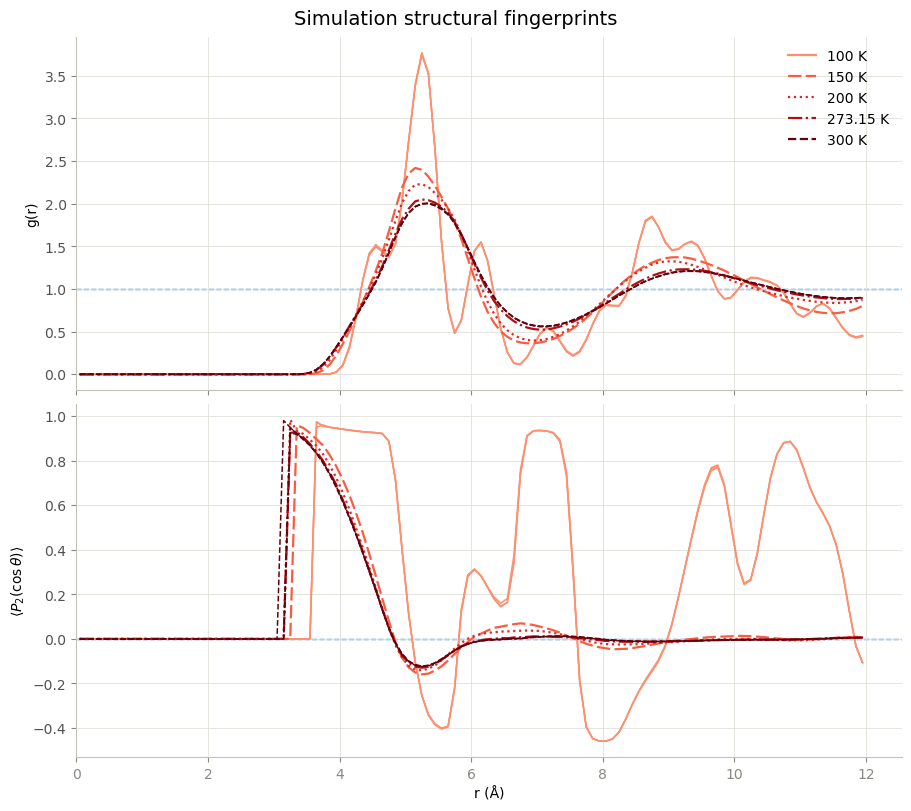

nematic order S -- 100 K 0.289, 150 K 0.027, 200 K 0.035, 273.15 K 0.037, 300 K 0.036
g(r) first peak (A) -- 100 K 5.25, 150 K 5.15, 200 K 5.25, 273.15 K 5.25, 300 K 5.35


In [5]:
from matplotlib.lines import Line2D

# (label, runs sharing this state point, color, linestyle, linewidth). Runs at one
# state point share a colour and dash: they are the same measurement repeated, so
# their spread is the message, not their identity. Both ensembles of three are
# drawn thinner so three overlaid curves do not read as one heavy band.
STATE_POINTS = [
    ("100 K", (results_1, results_2, results_3), T100, LS100, 1.1),
    ("150 K", (results_150,), T150, LS150, 1.6),
    ("200 K", (results_200,), T200, LS200, 1.6),
    ("273.15 K", (results_273,), T273, LS273, 1.6),
    ("300 K", (results_300_1, results_300_2, results_300_3), T300, LS300, 1.1),
]

# Stacked, sharing r: the orientational panel sits directly under the radial one
# so a feature at a given r lines up vertically between the two.
fig, (ax_rdf, ax_ocf) = plt.subplots(
    2, 1, figsize=(9, 8), sharex=True, constrained_layout=True
)

# radial distribution function g(r)
for _, runs, color, ls, lw in STATE_POINTS:
    for res in runs:
        ax_rdf.plot(res["rdf"]["r"], res["rdf"]["g_r"], lw=lw, ls=ls, color=color)
ax_rdf.axhline(1.0, lw=1, ls="--", zorder=0)
ax_rdf.set_ylabel("g(r)")

# orientational correlation <P2(cos θ)>(r)
for _, runs, color, ls, lw in STATE_POINTS:
    for res in runs:
        ax_ocf.plot(res["ocf"]["r"], res["ocf"]["s2_r"], lw=lw, ls=ls, color=color)
ax_ocf.axhline(0.0, lw=1, ls="--", zorder=0)
ax_ocf.set_xlabel("r (Å)")  # labelled once, on the bottom panel of the shared axis
ax_ocf.set_ylabel(r"$\langle P_2(\cos\theta)\rangle$")
ax_ocf.set_xlim(left=0)  # shared axis: no negative-r margin on either panel

chrome(ax_rdf)
chrome(ax_ocf)

# Legend in temperature order, matching the pale-to-deep ramp, so the key reads
# as the same ordering the curves carry.
handles = [Line2D([0], [0], color=color, lw=1.6, ls=ls, label=label)
          for label, _, color, ls, _ in STATE_POINTS]
ax_rdf.legend(handles=handles, frameon=False)

fig.suptitle("Simulation structural fingerprints",
             fontsize=14)
plt.show()

# The 150 K curves are the point of this figure now: at 100 K the g(r) still has
# resolved crystal shells and the OCF stays high out to the box edge, and by 150 K
# both have collapsed onto the 200-300 K liquid family.
print(f"nematic order S -- 100 K {scalars_1['S']:.3f}, 150 K {scalars_150['S']:.3f}, "
      f"200 K {scalars_200['S']:.3f}, 273.15 K {scalars_273['S']:.3f}, "
      f"300 K {agg(RUN_SCALARS_300, 'S')[0]:.3f}")
print(f"g(r) first peak (A) -- 100 K {scalars_1['rdf_peak_r']:.2f}, "
      f"150 K {scalars_150['rdf_peak_r']:.2f}, 200 K {scalars_200['rdf_peak_r']:.2f}, "
      f"273.15 K {scalars_273['rdf_peak_r']:.2f}, "
      f"300 K {agg(RUN_SCALARS_300, 'rdf_peak_r')[0]:.2f}")


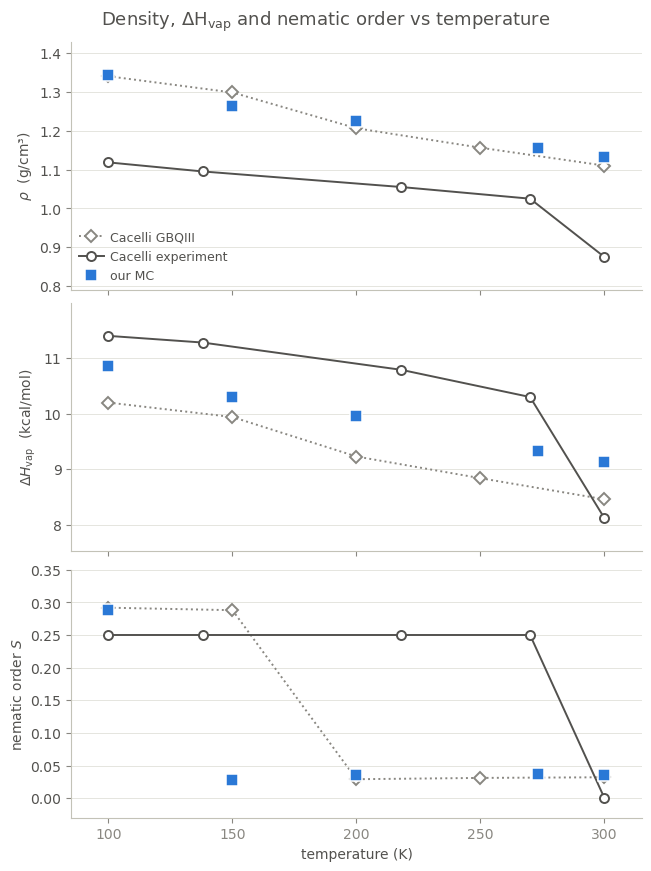

150 K vs GBQIII at the same T -- eta 0.027 (liquid) vs 0.288 (crystal), rho 1.264 vs 1.298 g/cm^3 (-2.6%). Their Table IV melting range is 150-200 K, so at 150 K they are still solid and we are already melted.

200 K vs GBQIII at the same T -- rho 1.224 vs 1.206 g/cm^3 (+1.5%), dH_vap 9.95 vs 9.23 kcal/mol (+7.8%), eta 0.035 vs 0.029. Experiment is still a crystal at 200 K, so its curve there is not a like-for-like partner.

300 K density -- ours 1.131 +- 0.0013, GBQIII 1.110, experiment 0.875 g/cm^3 (+1.9% vs GBQIII, +29.3% vs experiment). The run-to-run sigma is 0.12% of the mean, so neither offset is sampling noise.

100 K, 3 runs (mean +- 1 sigma, across starting jitter) -- rho 1.3436 +- 0.0001 g/cm^3, dH_vap 10.8577 +- 0.0002 kcal/mol, S 0.2884 +- 0.0010
300 K, 3 runs (mean +- 1 sigma, across seed) -- rho 1.1312 +- 0.0013 g/cm^3, dH_vap 9.1235 +- 0.0132 kcal/mol, S 0.0360 +- 0.0013


In [6]:
# Validation against Cacelli Fig 5: the three quantities they report across
# 100-400 K -- density, enthalpy of vaporization, nematic order -- with our five
# state points laid on top. Replaces the earlier "deviation from reference, at
# 100 K only" dot plot now that GBQIII's and experiment's own temperature
# dependence are digitised (previous cell), which makes a shared T axis the more
# informative comparison: it shows not just whether we land near a reference
# value, but whether we and GBQIII are tracking the same curve.
#
# Encoding: the two reference series are achromatic and recede (open markers,
# thin lines, grey/ink); ours is the only saturated colour and the only series
# drawn as bare points. Series identity is carried by marker shape and dash
# pattern as well as colour, so the figure survives grayscale printing and
# colour-vision deficiency -- worst-pair OKLab ΔE is 15.9 under simulated
# protanopia (target 8) and 17.8 under normal vision (floor 15).
GBQ_STYLE = dict(marker="D", ms=6.5, mfc="white", mec=MUTED, mew=1.4, ls=":", lw=1.4,
                 color=MUTED)
EXP_STYLE = dict(marker="o", ms=6.5, mfc="white", mec=INK, mew=1.4, ls="-", lw=1.4,
                 color=INK)
# One colour for every one of our points -- T is read off the shared x axis, so
# colouring by state point would spend a channel on information already there
# (that is why MC_COLOR is a fixed accent, not a step of the temperature ramp the
# structural figure above uses). The white ring keeps a square legible where it
# lands on a reference marker.
MC_STYLE = dict(marker="s", ms=8.5, mfc=MC_COLOR, mec="white", mew=1.1, ls="none")


def _fig5_series(d100, d_rest):
    """Sorted (T, dict) pairs: the 100 K state point plus the higher-T Fig 5 dict,
    with dHvap converted to kcal/mol alongside the eV it's stored in."""
    pts = {100.0: d100, **d_rest}
    return sorted((t, {**d, "dHvap_kcal": d["dHvap_ev"] * EV_TO_KCAL_PER_MOL})
                  for t, d in pts.items())


GBQ_SERIES = _fig5_series(CACELLI_GBQIII, CACELLI_GBQIII_T)
EXP_SERIES = _fig5_series(CACELLI_EXP, CACELLI_EXP_T)

# Our five state points, same keys as the reference series above. 100 K and 300 K
# are three runs each and carry a spread; 150, 200 and 273.15 K are single runs.
mc_rho_100, mc_rho_100_sd = agg(RUN_SCALARS_100, "rho")
mc_dH_100, mc_dH_100_sd = agg(RUN_SCALARS_100, "dHvap_ev")
mc_S_100, mc_S_100_sd = agg(RUN_SCALARS_100, "S")
mc_rho_300, mc_rho_300_sd = agg(RUN_SCALARS_300, "rho")
mc_dH_300, mc_dH_300_sd = agg(RUN_SCALARS_300, "dHvap_ev")
mc_S_300, mc_S_300_sd = agg(RUN_SCALARS_300, "S")
MC_POINTS = [
    (TEMP, {"rho": mc_rho_100, "rho_err": mc_rho_100_sd,
            "dHvap_kcal": mc_dH_100 * EV_TO_KCAL_PER_MOL,
            "dHvap_kcal_err": mc_dH_100_sd * EV_TO_KCAL_PER_MOL,
            "S": mc_S_100, "S_err": mc_S_100_sd}),
    (TEMP_COOL, {"rho": scalars_150["rho"],
                 "dHvap_kcal": scalars_150["dHvap_ev"] * EV_TO_KCAL_PER_MOL,
                 "S": scalars_150["S"]}),
    (TEMP_WARM, {"rho": scalars_200["rho"],
                 "dHvap_kcal": scalars_200["dHvap_ev"] * EV_TO_KCAL_PER_MOL,
                 "S": scalars_200["S"]}),
    (TEMP_MID, {"rho": scalars_273["rho"],
                "dHvap_kcal": scalars_273["dHvap_ev"] * EV_TO_KCAL_PER_MOL,
                "S": scalars_273["S"]}),
    (TEMP_HOT, {"rho": mc_rho_300, "rho_err": mc_rho_300_sd,
                "dHvap_kcal": mc_dH_300 * EV_TO_KCAL_PER_MOL,
                "dHvap_kcal_err": mc_dH_300_sd * EV_TO_KCAL_PER_MOL,
                "S": mc_S_300, "S_err": mc_S_300_sd}),
]

fig, (ax_rho, ax_dh, ax_eta) = plt.subplots(
    3, 1, figsize=(6.4, 8.6), constrained_layout=True, sharex=True)

for ax in (ax_rho, ax_dh, ax_eta):
    ax.set_xlim(85, 315)
    ax.set_xticks(range(100, 301, 50))
    ax.margins(y=0.18)   # headroom so no marker collides with a panel edge

for key, ax in (("rho", ax_rho), ("dHvap_kcal", ax_dh), ("S", ax_eta)):
    ax.plot(*zip(*[(t, d[key]) for t, d in GBQ_SERIES]), **GBQ_STYLE, zorder=3)
    ax.plot(*zip(*[(t, d[key]) for t, d in EXP_SERIES]), **EXP_STYLE, zorder=3)
    for T, d in MC_POINTS:
        # yerr is the sample std across the three runs at 100 K and at 300 K
        # (agg(), ddof=1); the 150/200/273.15 K points are single runs and carry
        # none. Lift the bar and cap artists above the marker so a bar is never
        # hidden by its white ring -- the replicas agree to 3-5 significant
        # figures, so these bars are a fraction of a point tall and the printed
        # sigmas below are the readable form of the same numbers.
        bars = ax.errorbar(T, d[key], yerr=d.get(f"{key}_err"), ecolor=MC_COLOR,
                           capsize=3, **MC_STYLE, zorder=5)
        for artist in (*bars.lines[1], *bars.lines[2]):
            artist.set_zorder(6)

# Shared x axis: labelled once, on the bottom panel.
ax_eta.set_xlabel("temperature (K)", color=INK)

ax_rho.set_ylabel(r"$\rho$  (g/cm³)", color=INK)
ax_dh.set_ylabel(r"$\Delta H_\mathrm{vap}$  (kcal/mol)", color=INK)
ax_eta.set_ylabel(r"nematic order $S$", color=INK)
ax_eta.set_ylim(-0.03, 0.35)

for ax in (ax_rho, ax_dh, ax_eta):
    chrome(ax, gaxis="y")   # y-only grid: nothing vertical to read here

handles = [
    Line2D([0], [0], **GBQ_STYLE, label="Cacelli GBQIII"),
    Line2D([0], [0], **EXP_STYLE, label="Cacelli experiment"),
    Line2D([0], [0], **MC_STYLE, label="our MC"),
]
ax_rho.legend(handles=handles, loc="lower left", frameon=False, fontsize=9,
              labelcolor=INK, handletextpad=0.5, borderaxespad=0.2)

fig.suptitle("Density, ΔH$_\\mathrm{vap}$ and nematic order vs temperature",
             fontsize=13, color=INK)
plt.show()

# 150 K is the one panel-crossing DISAGREEMENT with GBQIII, and it shows up in the
# eta panel rather than as a small offset: Fig 5's GBQIII marker there is a crystal,
# ours is a liquid, so the two points sit on opposite sides of a phase boundary and
# the rho and dH_vap gaps below are phase mismatches, not equation-of-state errors.
_eta_gbq_150 = dict(GBQ_SERIES)[150.0]["S"]
_rho_gbq_150 = dict(GBQ_SERIES)[150.0]["rho"]
print(f"150 K vs GBQIII at the same T -- eta {scalars_150['S']:.3f} (liquid) vs "
      f"{_eta_gbq_150:.3f} (crystal), rho {scalars_150['rho']:.3f} vs "
      f"{_rho_gbq_150:.3f} g/cm^3 "
      f"({100 * (scalars_150['rho'] / _rho_gbq_150 - 1):+.1f}%). Their Table IV melting "
      f"range is 150-200 K, so at 150 K they are still solid and we are already melted.")

# 200 K is the sharpest like-for-like test in the figure: Fig 5 carries a GBQIII
# marker at exactly this temperature, and both it and our run are liquids there
# (eta 0.029 and 0.035), so nothing has to be interpolated or phase-matched by eye.
_rho_gbq_200 = dict(GBQ_SERIES)[200.0]["rho"]
_rho_mc_200 = scalars_200["rho"]
_dh_gbq_200 = dict(GBQ_SERIES)[200.0]["dHvap_kcal"]
_dh_mc_200 = scalars_200["dHvap_ev"] * EV_TO_KCAL_PER_MOL
print(f"\n200 K vs GBQIII at the same T -- rho {_rho_mc_200:.3f} vs "
      f"{_rho_gbq_200:.3f} g/cm^3 ({100 * (_rho_mc_200 / _rho_gbq_200 - 1):+.1f}%), "
      f"dH_vap {_dh_mc_200:.2f} vs {_dh_gbq_200:.2f} kcal/mol "
      f"({100 * (_dh_mc_200 / _dh_gbq_200 - 1):+.1f}%), "
      f"eta {scalars_200['S']:.3f} vs {dict(GBQ_SERIES)[200.0]['S']:.3f}. "
      f"Experiment is still a crystal at 200 K, so its curve there is not a "
      f"like-for-like partner.")

# The headline read of the figure: at 300 K we sit on GBQIII, not on experiment --
# and with three runs there now, that offset can be quoted against a spread.
_rho_gbq_300 = dict(GBQ_SERIES)[300.0]["rho"]
_rho_exp_300 = dict(EXP_SERIES)[300.0]["rho"]
print(f"\n300 K density -- ours {mc_rho_300:.3f} +- {mc_rho_300_sd:.4f}, "
      f"GBQIII {_rho_gbq_300:.3f}, experiment {_rho_exp_300:.3f} g/cm^3 "
      f"({100 * (mc_rho_300 / _rho_gbq_300 - 1):+.1f}% vs GBQIII, "
      f"{100 * (mc_rho_300 / _rho_exp_300 - 1):+.1f}% vs experiment). The run-to-run "
      f"sigma is {100 * mc_rho_300_sd / mc_rho_300:.2f}% of the mean, so neither "
      f"offset is sampling noise.")

# The 100 K and 300 K error bars, as numbers: 1 sigma across the three runs at each.
# They are plotted, but the spread is far smaller than the marker, so print them too.
# The two sigmas mean different things -- see the run-loading cell: 100 K varies the
# starting jitter at fixed seed, 300 K varies the seed at fixed jitter.
print(f"\n100 K, {len(RUN_SCALARS_100)} runs (mean +- 1 sigma, across starting jitter) -- "
      f"rho {mc_rho_100:.4f} +- {mc_rho_100_sd:.4f} g/cm^3, "
      f"dH_vap {mc_dH_100 * EV_TO_KCAL_PER_MOL:.4f} +- "
      f"{mc_dH_100_sd * EV_TO_KCAL_PER_MOL:.4f} kcal/mol, "
      f"S {mc_S_100:.4f} +- {mc_S_100_sd:.4f}")
print(f"300 K, {len(RUN_SCALARS_300)} runs (mean +- 1 sigma, across seed) -- "
      f"rho {mc_rho_300:.4f} +- {mc_rho_300_sd:.4f} g/cm^3, "
      f"dH_vap {mc_dH_300 * EV_TO_KCAL_PER_MOL:.4f} +- "
      f"{mc_dH_300_sd * EV_TO_KCAL_PER_MOL:.4f} kcal/mol, "
      f"S {mc_S_300:.4f} +- {mc_S_300_sd:.4f}")


In [7]:
# Heat capacity: setup for the figure below. No plot in this cell.
#
# C_p is the one observable the vs-temperature figure above cannot score directly,
# because the model and the experiment are not measuring the same thing. A rigid
# coarse-grained ellipsoid has no internal degrees of freedom, so `HeatCapacity`
# returns the kinetic 3k_B plus the configurational fluctuation and nothing else.
# Real benzene also carries 3N-6 = 30 intramolecular vibrations. So
#
#     C_p(experiment)  ~  C_p(MC, as computed)  +  C_vib(T)
#
# and C_vib is a closed-form harmonic sum -- no simulation needed.

# Benzene gas-phase fundamentals (cm^-1, degeneracy); e-species are doubly
# degenerate, 30 modes total. Goodman, Ozkabak & Thakur, J. Phys. Chem. 95, 9044
# (1991) / Shimanouchi NSRDS-NBS 39. Condensed-phase shifts are a few cm^-1, so
# the gas-phase set is the right one for the crystal too.
BENZENE_MODES = [
    (3073, 1), (993, 1),                          # a1g
    (1350, 1),                                    # a2g
    (990, 1), (707, 1),                           # b2g
    (3056, 2), (1599, 2), (1178, 2), (606, 2),    # e2g
    (849, 2),                                     # e1g
    (673, 1),                                     # a2u
    (3057, 1), (1010, 1),                         # b1u
    (1309, 1), (1146, 1),                         # b2u
    (967, 2), (398, 2),                           # e2u
    (3064, 2), (1484, 2), (1038, 2),              # e1u
]
assert sum(g for _, g in BENZENE_MODES) == 30

def einstein(x):
    ex = np.exp(x)
    return x**2 * ex / (ex - 1.0) ** 2

def c_vib(T):
    """Harmonic intramolecular C_v of benzene, J/mol/K. Sanity check: this plus
    3R + R reproduces the gas-phase C_p at 298.15 K (82.2 vs 82.44 measured), so
    it is a closed-form prediction, not a fitted quantity."""
    T = np.asarray(T, dtype=float)
    return R_GAS * sum(g * einstein(nu * HC_OVER_K / T) for nu, g in BENZENE_MODES)

# Not plotted, but printed below because it sets how far the corrected number can
# be trusted: the MC treats the 6 external DOF *classically* while the experiment
# is quantum. Benzene's librations and optic translations sit at 40-140 cm^-1, so
# at 100 K they are partly frozen out and a classical run over-counts them.
# Modelled as 3 Debye acoustic + 21 Einstein optic branches per Pbca (Z=4) cell
# = 0.75 + 5.25 modes per molecule.
LATTICE_OPTIC = [40, 52, 58, 64, 79, 87, 96, 104, 112, 121, 130, 139]
THETA_DEBYE = 130.0   # K

def lattice_quantum_deficit(T):
    """Classical 6R minus the quantum lattice C_v, J/mol/K -- how much a
    classical simulation over-counts the external modes at temperature T."""
    x = THETA_DEBYE / float(T)
    u = np.linspace(1e-6, x, 4000)
    acoustic = 0.75 * R_GAS * 3 * x**-3 * np.trapezoid(
        u**4 * np.exp(u) / (np.exp(u) - 1) ** 2, u)
    optic = 5.25 * R_GAS * np.mean(
        [einstein(nu * HC_OVER_K / float(T)) for nu in LATTICE_OPTIC])
    return 6 * R_GAS - (acoustic + optic)

# Experimental C_p at our five state points, J/mol/K -- read from Oliver Table III
# (previous cell) via the same OLIVER_100/150/200/273/300 lookups the comparison
# table uses, so this figure and that table cannot disagree.
def _cp_J_per_mol_K(oliver_point):
    return oliver_point["Cp_evK"] * EV_TO_KJ_PER_MOL * 1e3

EXP_AT = {TEMP: _cp_J_per_mol_K(OLIVER_100), TEMP_COOL: _cp_J_per_mol_K(OLIVER_150),
         TEMP_WARM: _cp_J_per_mol_K(OLIVER_200), TEMP_MID: _cp_J_per_mol_K(OLIVER_273),
         TEMP_HOT: _cp_J_per_mol_K(OLIVER_300)}

cp_100_m, cp_100_sd = agg(RUN_SCALARS_100, "Cp")          # C_p / k_B, 100 K runs
cp_100, cp_100_err = cp_100_m * R_GAS, cp_100_sd * R_GAS
cp_300_m, cp_300_sd = agg(RUN_SCALARS_300, "Cp")          # C_p / k_B, 300 K runs
cp_300, cp_300_err = cp_300_m * R_GAS, cp_300_sd * R_GAS
cp_150 = scalars_150["Cp"] * R_GAS
cp_200 = scalars_200["Cp"] * R_GAS
cp_273 = scalars_273["Cp"] * R_GAS
POINTS = [(TEMP, cp_100, cp_100_err), (TEMP_COOL, cp_150, 0.0),
          (TEMP_WARM, cp_200, 0.0), (TEMP_MID, cp_273, 0.0),
          (TEMP_HOT, cp_300, cp_300_err)]

# C_p is a fluctuation quantity, so it converges far more slowly than a mean --
# the 300 K sigma below is the first direct measure of how slowly, and it is an
# order of magnitude looser in relative terms than the density spread printed
# above. Read every single-run C_p in this notebook with that width in mind.
print(f"C_p across the three 300 K runs: {cp_300:.2f} +- {cp_300_err:.2f} J/mol/K "
      f"({100 * cp_300_err / cp_300:.1f}% of the mean), against "
      f"{100 * mc_rho_300_sd / mc_rho_300:.2f}% for rho at the same state point.\n")

print(f"{'state point':<14}{'as computed':>13}{'+C_vib':>10}{'experiment':>13}"
      f"{'C_vib':>9}{'deficit':>9}")
for T, cp, _ in POINTS:
    cv, qd = float(c_vib(T)), lattice_quantum_deficit(T)
    print(f"{T:>8.2f} K    {cp:>10.2f}{cp + cv:>12.2f}{EXP_AT[T]:>12.2f}"
          f"{cv:>10.2f}{qd:>9.2f}")
print("\nJ/mol/K.  'deficit' = classical 6R minus the quantum lattice C_v, i.e. how"
      "\nmuch the classical run over-counts the external modes -- at 100 K it is 3x"
      "\nlarger than C_vib and of opposite sign, so the corrected number there is not"
      "\na clean test of the potential.  By 200 K the deficit has fallen to 1.8, so the"
      "\nquantum confound is largely gone there -- but 150, 200 and 273.15 K are all"
      "\nconfounded the other way instead: experiment is Oliver's SOLID branch (measured"
      "\nrows at 150 and 200 K, interpolated at 273.15 K) while all three of those runs"
      "\nmelted, so those gaps are phase mismatches, not C_p errors -- see the figure"
      "\nbelow.  Only 300 K compares a liquid against a liquid.")


C_p across the three 300 K runs: 60.20 +- 1.77 J/mol/K (2.9% of the mean), against 0.12% for rho at the same state point.

state point     as computed    +C_vib   experiment    C_vib  deficit
  100.00 K         51.01       53.11       50.42      2.10     6.55
  150.00 K         57.44       66.42       64.64      8.99     3.10
  200.00 K         62.19       82.24       83.72     20.05     1.79
  273.15 K         66.23      107.36      124.83     41.13     0.97
  300.00 K         60.20      109.70      136.48     49.50     0.81

J/mol/K.  'deficit' = classical 6R minus the quantum lattice C_v, i.e. how
much the classical run over-counts the external modes -- at 100 K it is 3x
larger than C_vib and of opposite sign, so the corrected number there is not
a clean test of the potential.  By 200 K the deficit has fallen to 1.8, so the
quantum confound is largely gone there -- but 150, 200 and 273.15 K are all
confounded the other way instead: experiment is Oliver's SOLID branch (measured
rows 

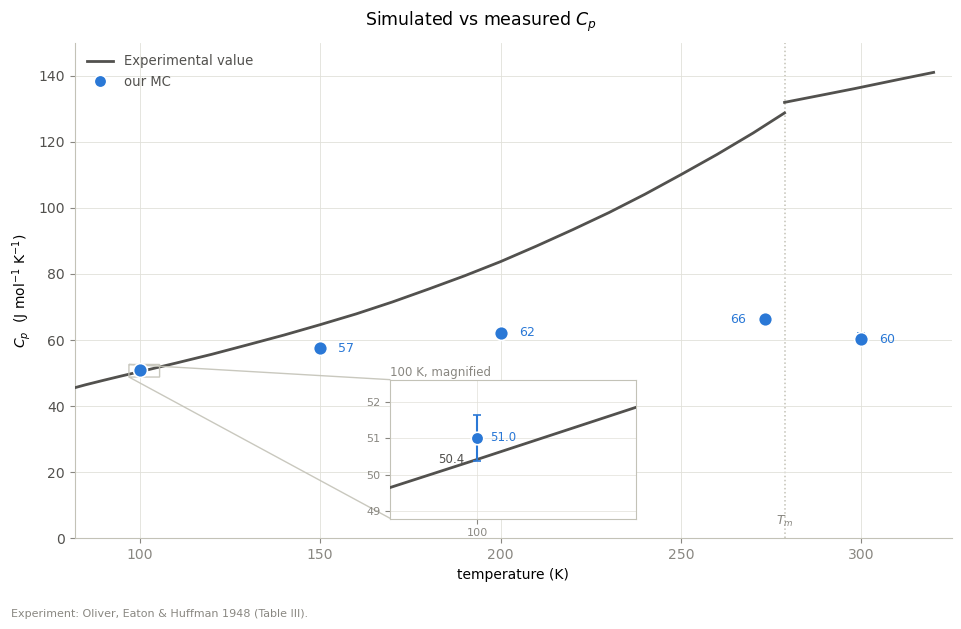

In [8]:
# Simulated C_p against Oliver's measured curve. Two series: Oliver Table III
# across temperature (two branches, a real jump at the melting point) and the MC
# value as computed.
#
# Colour carries the series, not the state point -- all five MC points are the
# same quantity computed the same way, and temperature already lives on the
# x-axis.
#
# The intramolecular C_vib term is deliberately NOT added here: the rigid
# coarse-grained model has no internal modes, so the gap to experiment is
# expected, and the correction is still being verified (cell above prints it).
# At 100 K the MC and measured values differ by less than 1 J/mol/K out of a
# 150-unit axis, so they are unreadable at full scale -- hence the magnified inset.
fig, ax = plt.subplots(figsize=(9.5, 5.8), constrained_layout=True)

ts = np.array([t for t, _ in OLIVER_CP_SOLID])
cs = np.array([c * CAL_TO_J for _, c in OLIVER_CP_SOLID])
ts_liq = np.array([t for t, _ in OLIVER_CP_LIQUID])
cs_liq = np.array([c * CAL_TO_J for _, c in OLIVER_CP_LIQUID])

def draw_series(target, ms=10):
    """The two Oliver branches and the five MC points. Drawn twice: once at full
    scale, once in the inset."""
    target.plot(ts, cs, "-", color=INK, lw=2, zorder=3)          # Oliver, solid phase
    target.plot(ts_liq, cs_liq, "-", color=INK, lw=2, zorder=3)  # Oliver, liquid phase
    for T, cp, err in POINTS:
        target.errorbar(T, cp, yerr=err if err else None, fmt="o", ms=ms,
                        mfc=MC_COLOR, mec="white", mew=1.2, ecolor=MC_COLOR,
                        capsize=3, zorder=5)

draw_series(ax)
ax.axvline(T_MELT, color=AXIS, lw=1.1, ls=":", zorder=0)
ax.annotate("$T_m$", (T_MELT, 4), fontsize=9, color=MUTED, ha="center")

# Label the 150, 200 and 300 K points to the right and the 273.15 K point to the
# left (it sits only 5.5 K from T_m and the liquid branch, so a right-hand label
# would collide with both). The 100 K point is resolved in the inset instead.
ax.annotate(f"{cp_150:.0f}", (TEMP_COOL, cp_150), textcoords="offset points",
            xytext=(13, 0), va="center", fontsize=9, color=MC_COLOR)
ax.annotate(f"{cp_200:.0f}", (TEMP_WARM, cp_200), textcoords="offset points",
            xytext=(13, 0), va="center", fontsize=9, color=MC_COLOR)
ax.annotate(f"{cp_300:.0f}", (TEMP_HOT, cp_300), textcoords="offset points",
            xytext=(13, 0), va="center", fontsize=9, color=MC_COLOR)
ax.annotate(f"{cp_273:.0f}", (TEMP_MID, cp_273), textcoords="offset points",
            xytext=(-13, 0), va="center", ha="right", fontsize=9, color=MC_COLOR)

ax.set_xlabel("temperature (K)")
ax.set_ylabel(r"$C_p$  (J mol$^{-1}$ K$^{-1}$)")
ax.set_xlim(82, 325)
ax.set_ylim(0, 150)
ax.legend(handles=[
    Line2D([0], [0], color=INK, lw=2, label="Experimental value"),
    Line2D([0], [0], marker="o", ls="none", ms=9, mfc=MC_COLOR, mec="white", mew=1.2,
           label="our MC")],
    frameon=False, fontsize=9.5, loc="upper left", labelcolor=INK)
chrome(ax)

# --- magnified 100 K inset ---------------------------------------------------
# Sits low in the panel: the 150 K point lands at ~57 J/mol/K, so an inset with
# its old 0.33 height would have put its top border and title through that
# marker's label.
axz = ax.inset_axes([0.36, 0.04, 0.28, 0.28])
draw_series(axz, ms=9)
axz.set_xlim(97, 105.5)
axz.set_ylim(48.8, 52.6)
# values only -- identity comes from the shared legend, so no repeated text.
# Opposite sides of the point so the two labels can't crowd each other.
axz.annotate(f"{EXP_AT[TEMP]:.1f}", (99.55, EXP_AT[TEMP]), fontsize=8.5, color=INK,
             va="center", ha="right")
axz.annotate(f"{cp_100:.1f}", (100.45, cp_100), fontsize=8.5, color=MC_COLOR,
             va="center", ha="left")
axz.set_xticks([100])
axz.set_yticks([49, 50, 51, 52])
axz.tick_params(labelsize=8, colors=MUTED)
axz.set_title("100 K, magnified", fontsize=8.5, color=MUTED, loc="left", pad=3)
for spine in axz.spines.values():
    spine.set_color(AXIS)
axz.grid(True, color=GRID, lw=0.5)
axz.set_axisbelow(True)

indicator = ax.indicate_inset_zoom(axz, edgecolor=AXIS, lw=1, alpha=0.9)
# Show the two connectors that land on the inset's LEFT corners. Matplotlib's
# default pairing here is (upper_left, lower_right), and that lower_right line
# runs to the inset's far bottom-right corner -- so it disappears behind the
# opaque inset background and reads as a line dying in the middle of the box.
# Order is (lower_left, upper_left, lower_right, upper_right).
for i, conn in enumerate(indicator.connectors):
    conn.set_visible(i in (0, 1))

fig.suptitle(r"Simulated vs measured $C_p$", fontsize=12.5)
fig.text(0.005, -0.04,
         f"Experiment: Oliver, Eaton & Huffman 1948 (Table III).",
         fontsize=8, color=MUTED, ha="left", va="top")
plt.show()


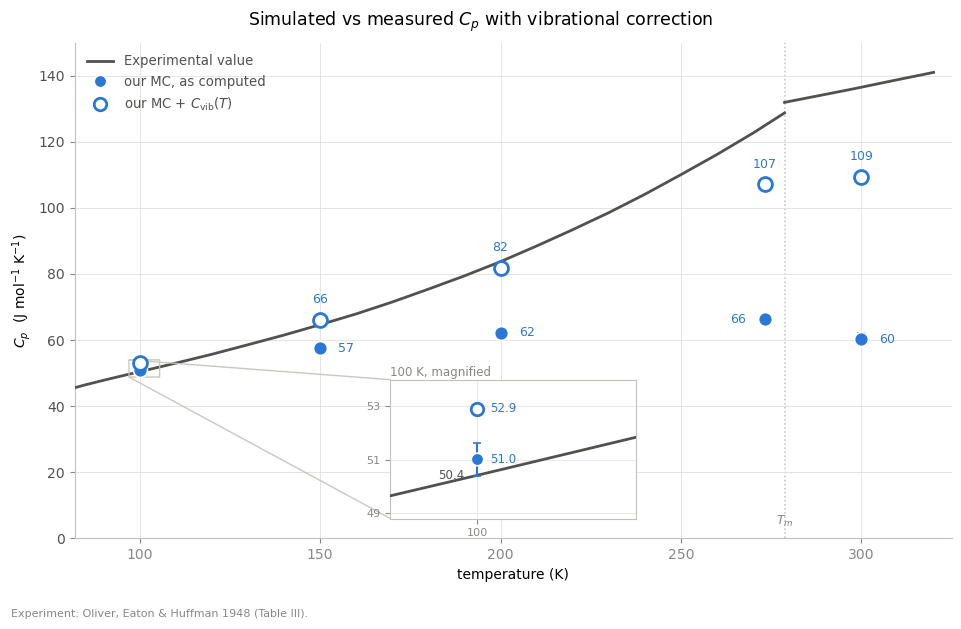

state point     as computed   C_vib    +C_vib  experiment  gap before  gap after
  100.00 K         51.01    1.90     52.92       50.42       +0.60      +2.50
  150.00 K         57.44    8.66     66.10       64.64       -7.21      +1.46
  200.00 K         62.19   19.72     81.91       83.72      -21.54      -1.81
  273.15 K         66.23   40.85    107.08      124.83      -58.60     -17.75
  300.00 K         60.20   49.24    109.45      136.48      -76.28     -27.03

J/mol/K.  The correction is strictly positive, so it can only help where the
simulation sits BELOW experiment. It does at 150, 200, 273.15 and 300 K, closing
most of the gap. At 100 K the run is already above, so adding C_vib moves it
further away -- and that is the honest reading, not a failure of C_vib: the
classical lattice deficit printed in the setup cell is 6.5 J/mol/K there,
several times larger and of opposite sign, so neither term alone is meaningful
at 100 K. The 150, 200 and 273.15 K comparisons are separately c

In [9]:
# The same figure, with the intramolecular correction applied.
#
# `HeatCapacity` returns 3k_B plus the configurational fluctuation -- the 6
# external DOF a rigid-body sampler has. Real benzene has 3 x 12 = 36, so what
# is missing is exactly its 30 intramolecular vibrations, and
# `asmcmc.utils.measurements.vibrational_heat_capacity` supplies them in closed form:
#
#     C_p(experiment)  ~  C_p(MC, as computed)  +  C_vib(T)
#
# Hollow markers are the corrected values. Same hue deliberately: this is the same
# measurement plus an analytic term, not a second series.
from asmcmc.utils.measurements import (BENZENE_FUNDAMENTALS, EV_PER_K_TO_J_PER_MOL_K,
                                 vibrational_heat_capacity)


def c_vib_module(temp):
    """Intramolecular C_vib in J/mol/K, from the packaged implementation.

    Distinct from the notebook-local `c_vib` defined in the setup cell: that one
    uses Goodman/Ozkabak's fundamentals, this one Shimanouchi's (NSRDS-NBS 39, via
    the NIST WebBook). The two published sets differ by a few cm^-1 on the lowest
    modes, which is the whole of the small discrepancy printed below.
    """
    return float(vibrational_heat_capacity(temp, BENZENE_FUNDAMENTALS)) * EV_PER_K_TO_J_PER_MOL_K


CORRECTED = [(t, cp + c_vib_module(t), err) for t, cp, err in POINTS]

# Recomputed rather than inherited from the cell above, so this cell stands alone.
ts = np.array([t for t, _ in OLIVER_CP_SOLID])
cs = np.array([c * CAL_TO_J for _, c in OLIVER_CP_SOLID])
ts_liq = np.array([t for t, _ in OLIVER_CP_LIQUID])
cs_liq = np.array([c * CAL_TO_J for _, c in OLIVER_CP_LIQUID])

fig, ax = plt.subplots(figsize=(9.5, 5.8), constrained_layout=True)


def draw_series(target, ms=10):
    """Oliver's two branches, the five MC points, and their corrected twins."""
    target.plot(ts, cs, "-", color=INK, lw=2, zorder=3)
    target.plot(ts_liq, cs_liq, "-", color=INK, lw=2, zorder=3)
    for (t, cp, err), (_, cp_c, _) in zip(POINTS, CORRECTED):
        target.errorbar(t, cp, yerr=err if err else None, fmt="o", ms=ms,
                        mfc=MC_COLOR, mec="white", mew=1.2, ecolor=MC_COLOR,
                        capsize=3, zorder=5)
        target.plot(t, cp_c, "o", ms=ms, mfc="white", mec=MC_COLOR, mew=2, zorder=6)


draw_series(ax)
ax.axvline(T_MELT, color=AXIS, lw=1.1, ls=":", zorder=0)
ax.annotate("$T_m$", (T_MELT, 4), fontsize=9, color=MUTED, ha="center")

# 100 K is resolved in the inset; label the other four, corrected above and raw
# to the side (273.15 K to the left, it sits 5.5 K from T_m and the liquid branch).
for t, cp_c, _ in CORRECTED[1:]:
    ax.annotate(f"{cp_c:.0f}", (t, cp_c), textcoords="offset points",
                xytext=(0, 12), ha="center", fontsize=9, color=MC_COLOR)
ax.annotate(f"{cp_150:.0f}", (TEMP_COOL, cp_150), textcoords="offset points",
            xytext=(13, 0), va="center", fontsize=9, color=MC_COLOR)
ax.annotate(f"{cp_200:.0f}", (TEMP_WARM, cp_200), textcoords="offset points",
            xytext=(13, 0), va="center", fontsize=9, color=MC_COLOR)
ax.annotate(f"{cp_300:.0f}", (TEMP_HOT, cp_300), textcoords="offset points",
            xytext=(13, 0), va="center", fontsize=9, color=MC_COLOR)
ax.annotate(f"{cp_273:.0f}", (TEMP_MID, cp_273), textcoords="offset points",
            xytext=(-13, 0), va="center", ha="right", fontsize=9, color=MC_COLOR)

ax.set_xlabel("temperature (K)")
ax.set_ylabel(r"$C_p$  (J mol$^{-1}$ K$^{-1}$)")
ax.set_xlim(82, 325)
ax.set_ylim(0, 150)
ax.legend(handles=[
    Line2D([0], [0], color=INK, lw=2, label="Experimental value"),
    Line2D([0], [0], marker="o", ls="none", ms=9, mfc=MC_COLOR, mec="white", mew=1.2,
           label="our MC, as computed"),
    Line2D([0], [0], marker="o", ls="none", ms=9, mfc="white", mec=MC_COLOR, mew=2,
           label=r"our MC $+\ C_\mathrm{vib}(T)$")],
    frameon=False, fontsize=9.5, loc="upper left", labelcolor=INK)
chrome(ax)

# --- magnified 100 K inset (y-range widened to hold the corrected point) ------
# Lowered for the same reason as the previous figure: the 150 K raw point at
# ~57 J/mol/K would otherwise be labelled on top of the inset's top border.
axz = ax.inset_axes([0.36, 0.04, 0.28, 0.28])
draw_series(axz, ms=9)
axz.set_xlim(97, 105.5)
axz.set_ylim(48.8, 54.0)
axz.annotate(f"{EXP_AT[TEMP]:.1f}", (99.55, EXP_AT[TEMP]), fontsize=8.5, color=INK,
             va="center", ha="right")
axz.annotate(f"{cp_100:.1f}", (100.45, cp_100), fontsize=8.5, color=MC_COLOR,
             va="center", ha="left")
axz.annotate(f"{CORRECTED[0][1]:.1f}", (100.45, CORRECTED[0][1]), fontsize=8.5,
             color=MC_COLOR, va="center", ha="left")
axz.set_xticks([100])
axz.set_yticks([49, 51, 53])
axz.tick_params(labelsize=8, colors=MUTED)
axz.set_title("100 K, magnified", fontsize=8.5, color=MUTED, loc="left", pad=3)
for spine in axz.spines.values():
    spine.set_color(AXIS)
axz.grid(True, color=GRID, lw=0.5)
axz.set_axisbelow(True)

indicator = ax.indicate_inset_zoom(axz, edgecolor=AXIS, lw=1, alpha=0.9)
for i, conn in enumerate(indicator.connectors):
    conn.set_visible(i in (0, 1))

fig.suptitle(r"Simulated vs measured $C_p$ with vibrational correction",
             fontsize=12.5)
fig.text(0.005, -0.04,
         "Experiment: Oliver, Eaton & Huffman 1948 (Table III).  ",
         fontsize=8, color=MUTED, ha="left", va="top")
plt.show()

print(f"{'state point':<14}{'as computed':>13}{'C_vib':>8}{'+C_vib':>10}"
      f"{'experiment':>12}{'gap before':>12}{'gap after':>11}")
for (t, cp, _), (_, cp_c, _) in zip(POINTS, CORRECTED):
    print(f"{t:>8.2f} K    {cp:>10.2f}{c_vib_module(t):>8.2f}{cp_c:>10.2f}"
          f"{EXP_AT[t]:>12.2f}{cp - EXP_AT[t]:>+12.2f}{cp_c - EXP_AT[t]:>+11.2f}")

print("\nJ/mol/K.  The correction is strictly positive, so it can only help where the"
      "\nsimulation sits BELOW experiment. It does at 150, 200, 273.15 and 300 K, closing"
      "\nmost of the gap. At 100 K the run is already above, so adding C_vib moves it"
      "\nfurther away -- and that is the honest reading, not a failure of C_vib: the"
      "\nclassical lattice deficit printed in the setup cell is 6.5 J/mol/K there,"
      "\nseveral times larger and of opposite sign, so neither term alone is meaningful"
      "\nat 100 K. The 150, 200 and 273.15 K comparisons are separately confounded: all"
      "\nthree runs melted while Oliver's branch is still solid, so a close corrected"
      "\nagreement there is a liquid being scored against a crystal, not a hit. 300 K is"
      "\nthe only row where both sides are liquids -- and it is also the only row with a"
      "\nrun-to-run sigma on the simulated value.")

print(f"\nC_vib vs the notebook-local c_vib (different published fundamentals):")
for t, _, _ in POINTS:
    print(f"  {t:>7.2f} K   module {c_vib_module(t):>7.3f}   local {float(c_vib(t)):>7.3f}"
          f"   diff {c_vib_module(t) - float(c_vib(t)):>+6.3f}")


In [10]:
# Rows are "quantity (unit)", columns are runs and sources -- the layout of the
# Measurement_Results sheet in docs/. Two specs drive it: ROWS says what a row is
# and how to get there from the base unit, COLUMNS says where each column's numbers
# come from. A source that never reports a quantity simply lacks the key, and the
# cell is left empty.
#
# A row exists per unit that some source actually publishes in -- eV, k_B and eV/Å³
# (this code), kcal/mol (Cacelli), cal/(mol K) and atm (Oliver / Cacelli) -- plus
# kJ/mol and J/(mol K), the modern units the figures above and the meeting workbook
# already use. cal/mol for energies is dropped as a bare x1000 of the kcal/mol row.
#
# Every Cacelli column carries its temperature, because Fig 5 gives ρ, ΔH_vap and η
# across 100-400 K and the two series are on different temperature grids -- so the
# columns are the state points each source actually reports, not a shared T axis.
import pandas as pd

ROWS = [
    # (key in the run/reference dicts, row label, factor from the base unit)
    ("temp",       "T (K)",                1.0),
    ("pressure",   "P (eV/A^3)",           1.0),
    ("pressure",   "P (atm)",              1.0 / ATM_IN_EV_PER_A3),
    ("rho",        "rho (g/cm^3)",         1.0),
    ("V_per_mol",  "V/N (A^3)",            1.0),
    ("UN",         "U/N (eV)",             1.0),
    ("UN",         "U/N (kcal/mol)",       EV_TO_KCAL_PER_MOL),
    ("UN",         "U/N (kJ/mol)",         EV_TO_KJ_PER_MOL),
    ("HN",         "H/N (eV)",             1.0),
    ("HN",         "H/N (kcal/mol)",       EV_TO_KCAL_PER_MOL),
    ("HN",         "H/N (kJ/mol)",         EV_TO_KJ_PER_MOL),
    ("dHvap_ev",   "dH_vap (eV)",          1.0),
    ("dHvap_ev",   "dH_vap (kcal/mol)",    EV_TO_KCAL_PER_MOL),
    ("dHvap_ev",   "dH_vap (kJ/mol)",      EV_TO_KJ_PER_MOL),
    ("Cp_evK",     "C_p (k_B)",            1.0 / BOLTZCONST),
    ("Cp_evK",     "C_p (cal/mol/K)",      EV_TO_KCAL_PER_MOL * 1e3),
    ("Cp_evK",     "C_p (J/mol/K)",        EV_TO_KJ_PER_MOL * 1e3),
    ("S",          "S / eta",              1.0),
    ("theta",      "theta (deg)",          1.0),
    ("psi",        "psi (deg)",            1.0),
    ("a",          "a (A)",                1.0),
    ("b",          "b (A)",                1.0),
    ("c",          "c (A)",                1.0),
    ("rdf_peak_r", "g(r) 1st peak, r (A)", 1.0),
    ("rdf_min_r",  "g(r) 1st min, r (A)",  1.0),
    ("n_coord",    "n_coord",              1.0),
]

# One column per run, never a mean/sigma pair: both 100 K and 300 K have three runs
# now, and collapsing either into an average would hide exactly the run-to-run
# spread those replicas exist to show. The former "Run 1/2/3" columns are labelled
# with their temperature for the same reason -- with two ensembles in the table, a
# bare run number no longer says which state point it belongs to.
COLUMNS = [
    ("MC 100 K 1", scalars_1), ("MC 100 K 2", scalars_2), ("MC 100 K 3", scalars_3),
    ("MC 150 K", scalars_150), ("MC 200 K", scalars_200), ("MC 273.15 K", scalars_273),
    ("MC 300 K 1", scalars_300_1), ("MC 300 K 2", scalars_300_2),
    ("MC 300 K 3", scalars_300_3),
    # Cacelli: 100 K from Table V, the rest digitised from Fig 5
    ("Cacelli GBQIII 100 K", CACELLI_GBQIII),
    *[(f"Cacelli GBQIII {T} K", CACELLI_GBQIII_T[T]) for T in (150, 200, 250, 300)],
    ("Cacelli Exp 100 K", CACELLI_EXP),
    *[(f"Cacelli Exp {T} K", CACELLI_EXP_T[T]) for T in (138, 218, 270, 300)],
    ("Oliver 100 K", OLIVER_100), ("Oliver 150 K", OLIVER_150),
    ("Oliver 273.15 K", OLIVER_273), ("Oliver 300 K", OLIVER_300),
    ("CRC liquid 298 K", CRC_298),
]

comparison = pd.DataFrame(
    {name: [src[key] * factor if key in src else np.nan
            for key, _, factor in ROWS]
     for name, src in COLUMNS},
    index=[label for _, label, _ in ROWS],
)
comparison.index.name = "quantity (unit)"

transitions = pd.DataFrame(
    TRANSITIONS, index=["Cacelli GBQIII", "Cacelli Experiment", "Oliver"]).T
transitions.index.name = "quantity (unit)"

# --- save -----------------------------------------------------------------
OUT_DIR = "../results/validation"
CSV_PATH = f"{OUT_DIR}/scalar_comparison.csv"
CSV_TRANSITIONS = f"{OUT_DIR}/scalar_comparison_transitions.csv"
XLSX_PATH = f"{OUT_DIR}/scalar_comparison.xlsx"

comparison.to_csv(CSV_PATH)
transitions.to_csv(CSV_TRANSITIONS)
with pd.ExcelWriter(XLSX_PATH) as xl:
    comparison.to_excel(xl, sheet_name="state_points")
    transitions.to_excel(xl, sheet_name="transitions")
for p in (CSV_PATH, CSV_TRANSITIONS, XLSX_PATH):
    print(f"wrote {p}  ({os.path.getsize(p) / 1024:.0f} kB)")

LEGEND = f"""
Sources
  Cacelli GBQIII / Exp 100 K  {CACELLI}
    a, b, c, theta, psi   Table V (T = 100 K; the experimental column is the measured
                          structure extrapolated to 100 K)
    rho, V/N              DERIVED from the Table V cell as a.b.c/Z with Z = 4 -- Table V
                          tabulates neither, and neither was read off a figure
    S / eta               GBQIII from inverting their own theta(eta) on Table V's
                          theta = 46.6 deg. The experimental 0.25 was ASSUMED by them for
                          the whole crystal range (p. 3653), not measured -- their own
                          theta = 46.4 deg would imply 0.287
    dH_vap                Fig 5 at 100 K. The experimental curve has no marker there, so
                          11.4 is its line endpoint; GBQIII has one, at 10.22
    g(r) rows             p. 3655 -- their 300 K LIQUID, not the 100 K crystal
    n_coord (experiment)  12, "common to the crystal and liquid phase" (p. 3655)
  Cacelli GBQIII 150-300 K, Cacelli Exp 138-300 K   Fig 5, DIGITISED
    what                  Fig 5 is the only place the paper reports anything away from
                          100 K, and it plots exactly three quantities: rho, dH_vap, eta.
                          V/N is rho in other units. Every other row is empty for these
                          columns because the paper does not report it there
    how                   panel frames located, calibrated on the tick marks (all three
                          panels' frames land on round values: 0-15 kcal/mol, 0-1.5 g/mL,
                          0-1 eta), then each marker centroid taken. Overlapping markers
                          were separated by fitting the two shapes. Uncertainty is about
                          one marker radius: +-0.1 kcal/mol, +-0.01 in rho and eta
    checks                five independent ones, all passing. At 100 K the digitised
                          GBQIII rho 1.332 and eta 0.293 reproduce the 1.3397 and 0.2919
                          derived from Table V (0.6% / 0.4%). Near 300 K the digitised
                          experimental rho 0.875 and dH_vap 33.97 kJ/mol match CRC's 0.877
                          and 33.8 at 298 K (0.2% / 0.5%). And the experimental dH_vap
                          drop across melting, 10.30 - 8.12 = 2.18 kcal/mol, recovers
                          Oliver's heat of fusion 2.3581 to 8% -- loose only because those
                          two points straddle the 278.69 K transition at 270 and 300 K
                          rather than sitting on it
    grids                 the two series are NOT on a common T axis. Models were run at
                          100/150/.../400 K; the experimental points sit where measurements
                          exist -- 138, 218, 270, 300 K (and 353, the boiling point)
    phases                GBQIII is a crystal at 100-150 K and a liquid from 200 K up (its
                          eta falls 0.288 -> 0.029 in between, which is the Table IV
                          melting range 150-200 K). Experiment is a crystal to 270 K and a
                          liquid at 300 K, melting at 278.69 K
  Oliver 100 / 150 / 273.15 / 300 K  {OLIVER}
    C_p                   Table III, C_satd. The 100 K (12.050), 150 K (15.450), 200 K
                          (20.010) and 300 K (32.620) cal/(mol K) entries are measured
                          rows; 273.15 K is INTERPOLATED between his 270 K and 278.69 K
                          solid rows. (The 200 K column is not carried here -- it appears
                          in the C_p figures above via the same lookup.)
    P                     left blank on purpose: C_satd is the SATURATED condensed phase,
                          so its pressure is benzene's own vapour pressure (negligible at
                          100 K, ~0.13 atm near 300 K). Every other column is at 1 atm
  CRC liquid 298 K        liquid benzene, rho 0.877 g/cm3 and dH_vap 33.8 kJ/mol at
                          298.15 K -- 1.85 K below the 300 K runs it sits beside

Our runs
  MC 100 K 1/2/3          one seed (45), three starting jitters (0, 0.10, 0.15) -- their
                          spread is sensitivity to the starting configuration
  MC 300 K 1/2/3          one starting jitter (0.15), three seeds (30, 1151, 12321) --
                          their spread is ordinary sampling noise. C_p scatters ~5% across
                          them while rho scatters ~0.1%, which is the width to keep in mind
                          for every single-run C_p in the table
  MC 150 / 200 / 273.15 K single runs, no spread available

Read with care
  The 300 K columns are the like-for-like test of our sampler against EXPERIMENT, because
    there GBQIII, our MC runs and experiment are all liquids. Our rho sits within ~2% of
    Cacelli's own GBQIII at the same T and P, and BOTH are ~29% above the measured 0.875
    -- so the over-density is the potential's, not our sampler's.
  The 200 K columns are the like-for-like test against GBQIII ITSELF, and the tightest one
    available: Fig 5 has a GBQIII marker at exactly 200 K, both it and our run are liquids
    there (eta 0.029 and 0.035), and nothing has to be interpolated. Experiment is still a
    crystal at 200 K, so the Cacelli Exp columns are NOT a partner for this one.
  The 150 K columns are where we and GBQIII DISAGREE, and the disagreement is a phase, not
    a number: Fig 5 has GBQIII at eta 0.288 there (still a crystal, consistent with the
    150-200 K melting range of Table IV) while our run is a liquid at eta 0.027. So our
    melting sits between 100 K (crystal) and 150 K, at or below the BOTTOM of their range
    rather than inside it, and ~130 K below the real 278.69 K. Read the rho and dH_vap
    gaps in those columns as a crystal-vs-liquid mismatch, not as an equation of state.
  Provenance step at 100 -> 150 K in the GBQIII rho row: 100 K is derived from Table V
    lattice constants, 150 K onward is digitised from Fig 5. The digitised 100 K value is
    1.332 against the derived 1.3397, so read the 0.6% step as provenance, not physics.
  Phase mismatch at 150 and 273.15 K (and at 200 K, in the C_p figures): those runs melted
    but all three temperatures are below the real melting point 278.69 K, so Oliver's
    columns there are CRYSTALS. GBQIII melts at 150-200 K (Cacelli Table IV, the T_melting
    row of the second table) and ours at or below 150 K, ~130 K too low -- that is the
    cause, not a C_p error.
  a, b, c and theta for every run above 100 K are NOT lattice constants or a tilt angle:
    those runs melted, so a/b/c are mean box edges over the original supercell reps
    and theta comes from Cacelli's theta(eta), which assumes the crystal texture. theta is
    left out of the Fig 5 columns for the same reason.
  n_coord at 100 K is criterion-dependent -- the crystal's g(r) shells overlap and its
    minima at ~5.8 and ~6.8 A give 10.0 or ~14. Do not read it against Cacelli's 12.5,
    which is a liquid. The 150 / 200 / 273.15 / 300 K values (~12.9-13.3) are the
    like-for-like comparison.
  S / eta is texture-degenerate: ~0-0.25 for a good 4-domain crystal, >=0.25 for Cacelli's
    2-spot texture, ~0 for a glass or a liquid. Read it with the OCF curve above.
  C_p carries no intramolecular vibrations -- see the C_vib cells above before comparing
    any C_p row to an experimental one.
"""


def show(df):
    """Display copy: 5 significant figures, '-' where a source reports nothing."""
    text = df.map(lambda v: "-" if pd.isna(v)
                  else f"{v:.5g}" if isinstance(v, float) else str(v))
    with pd.option_context("display.max_columns", 40, "display.max_rows", 60,
                           "display.width", 400):
        display(text)


print(f"\ncomparison  {comparison.shape[0]} rows x {comparison.shape[1]} columns")
show(comparison)
print(f"transitions  {transitions.shape[0]} rows x {transitions.shape[1]} columns "
      "(published references with no simulation counterpart)")
show(transitions)
print(LEGEND)


wrote ../results/validation/scalar_comparison.csv  (6 kB)
wrote ../results/validation/scalar_comparison_transitions.csv  (1 kB)
wrote ../results/validation/scalar_comparison.xlsx  (10 kB)

comparison  26 rows x 24 columns


,MC 100 K 1,MC 100 K 2,MC 100 K 3,MC 150 K,MC 200 K,MC 273.15 K,MC 300 K 1,MC 300 K 2,MC 300 K 3,Cacelli GBQIII 100 K,Cacelli GBQIII 150 K,Cacelli GBQIII 200 K,Cacelli GBQIII 250 K,Cacelli GBQIII 300 K,Cacelli Exp 100 K,Cacelli Exp 138 K,Cacelli Exp 218 K,Cacelli Exp 270 K,Cacelli Exp 300 K,Oliver 100 K,Oliver 150 K,Oliver 273.15 K,Oliver 300 K,CRC liquid 298 K
quantity (unit),,,,,,,,,,,,,,,,,,,,,,,,
T (K),100,100,100,150,200,273.15,300,300,300,100,150,200,250,300,100,138,218,270,300,100,150,273.15,300,298.15
P (eV/A^3),6.3242e-07,6.3242e-07,6.3242e-07,6.3242e-07,6.3242e-07,6.3242e-07,6.3242e-07,6.3242e-07,6.3242e-07,6.3242e-07,6.3242e-07,6.3242e-07,6.3242e-07,6.3242e-07,6.3242e-07,6.3242e-07,6.3242e-07,6.3242e-07,6.3242e-07,-,-,-,-,6.3242e-07
P (atm),1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,-,-,-,-,1
rho (g/cm^3),1.3437,1.3436,1.3436,1.264,1.2238,1.1547,1.1298,1.1324,1.1314,1.3397,1.298,1.206,1.156,1.11,1.1183,1.095,1.055,1.025,0.875,-,-,-,-,0.877
V/N (A^3),96.525,96.536,96.534,102.62,105.99,112.33,114.81,114.54,114.64,96.815,99.927,107.55,112.2,116.85,115.99,118.45,122.94,126.54,148.23,-,-,-,-,-
U/N (eV),-0.46227,-0.46228,-0.46229,-0.4338,-0.4143,-0.3809,-0.36923,-0.37037,-0.36996,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-
U/N (kcal/mol),-10.66,-10.66,-10.661,-10.004,-9.5539,-8.7838,-8.5147,-8.5409,-8.5316,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-
U/N (kJ/mol),-44.602,-44.603,-44.604,-41.855,-39.973,-36.751,-35.626,-35.735,-35.696,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-
H/N (eV),-0.46221,-0.46222,-0.46223,-0.43374,-0.41423,-0.38083,-0.36916,-0.37029,-0.36989,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-


transitions  11 rows x 3 columns (published references with no simulation counterpart)


,Cacelli GBQIII,Cacelli Experiment,Oliver
quantity (unit),,,
dH_melting (kcal/mol),0.36,2.2,-
dH_melting (kJ/mol),1.5062,9.2048,-
drho_melting (g/cm^3),0.05,0.12,-
T_melting (K),150-200,278,278.691 ± 0.010
dH_fusion (cal/mol),-,-,2358.1
dH_fusion (kcal/mol),-,-,2.3581
dH_fusion (kJ/mol),-,-,9.8663
S saturated liquid @298.16 K (cal/mol/K),-,-,41.411
S saturated liquid @298.16 K (J/mol/K),-,-,173.26



Sources
  Cacelli GBQIII / Exp 100 K  Cacelli, Cinacchi, Prampolini & Tani, J. Chem. Phys. 120, 3648 (2004)
    a, b, c, theta, psi   Table V (T = 100 K; the experimental column is the measured
                          structure extrapolated to 100 K)
    rho, V/N              DERIVED from the Table V cell as a.b.c/Z with Z = 4 -- Table V
                          tabulates neither, and neither was read off a figure
    S / eta               GBQIII from inverting their own theta(eta) on Table V's
                          theta = 46.6 deg. The experimental 0.25 was ASSUMED by them for
                          the whole crystal range (p. 3653), not measured -- their own
                          theta = 46.4 deg would imply 0.287
    dH_vap                Fig 5 at 100 K. The experimental curve has no marker there, so
                          11.4 is its line endpoint; GBQIII has one, at 10.22
    g(r) rows             p. 3655 -- their 300 K LIQUID, not the 100 K crystal
    n_coord 